In [737]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pprint

In [859]:
def glls(S, X, CovX, E, CovE):
    # Calculate response
    C = S @ X

    # GLLS equations
    dX = CovX @ S.T @ np.linalg.pinv((S @ CovX @ S.T + CovE)) @ np.divide(E-C, C)
    X_post = dX * X + X
    Cov_X_post = CovX - CovX @ S.T @ np.linalg.pinv((S @ CovX @ S.T + CovE)) @ S @ CovX.T
    for i, x in enumerate(X_post):
        print(f"Value X[{i}]: {x:.3f} +/- {np.sqrt(np.diag(Cov_X_post))[i]:.3f}")
    # Calculate posterior response
    C_post = S @ X_post
    Cov_C_post  = S @ Cov_X_post @ S.T
    for i, c in enumerate(C_post):
        print(f"Value[{i}]: {c:.2f} +/- {np.sqrt(np.diag(Cov_C_post))[i]:.2f}")
    return X_post, Cov_X_post, C_post, Cov_C_post

In [860]:
# Design matrix
S0 = np.array([
    [1, 1],
    [3, -2],
    [4, 1],
])

# Prior values and relative uncertainty
X0 = np.array([1.5, 2])
Cov_X0 = np.array([
    [(X0[0]*0.05)**2, 0],
    [0, (X0[1]*0.08)**2]
])

# Experimental measurements and its relative uncertainty
E0 = np.array([3, 1, 10])
Cov_E0 = np.array([
    [(E0[0]*0.02)**2, 0, 0],
    [0, (E0[1]*0.02)**2, 0],
    [0, 0, (E0[2]*0.02)**2]
])

In [861]:
def func(X):
    C0 = X[2] * (X[0] + X[1])
    C1 = X[2] * (3*X[0] - 2*X[1])
    C2 = X[2] * (4*X[0] + X[1])
    C3 = X[2]
    return np.array([C0, C1, C2, C3])

# Prior values and relative uncertainty
X1 = np.array([1.5, 2, 1.0])
Cov_X1 = np.array([
    [(X1[0]*0.05)**2, 0, 0],
    [0, (X1[1]*0.08)**2, 0],
    [0, 0, (X1[2]*0.10)**2]
])

# Experimental measurements and its relative uncertainty
E1 = np.array([3, 1, 10, 1])

Cov_E1 = np.array([
    [(E1[0]*0.02)**2, 0, 0, 0],
    [0, (E1[1]*0.02)**2, 0, 0],
    [0, 0, (E1[2]*0.02)**2, 0],
    [0, 0, 0, (E1[3]*0.02)**2]
])

In [862]:
C0 = S0 @ X0
Cov_C_prior0 = S0 @ Cov_X0 @ S0.T

In [863]:
X_post0, Cov_X_post0, C_post0, Cov_C_post0 = glls(S0, X0, Cov_X0, E0, Cov_E0)

Value X[0]: 1.706 +/- 0.019
Value X[1]: 1.415 +/- 0.029
Value[0]: 3.12 +/- 0.05
Value[1]: 2.29 +/- 0.02
Value[2]: 8.24 +/- 0.11


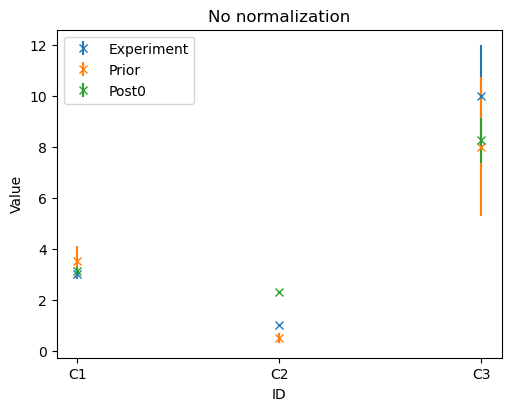

In [864]:
fig, ax = plt.subplots(figsize=(5,4), layout="constrained")

ax.errorbar(["C1", "C2", "C3"], E0, yerr=E0 * np.sqrt(np.diag(Cov_E0)), label="Experiment", ls="none", marker="x")
ax.errorbar(["C1", "C2", "C3"], C0, yerr=C0 * np.sqrt(np.diag(Cov_C_prior0)), label="Prior", ls="none", marker="x")
ax.errorbar(["C1", "C2", "C3"], C_post0, yerr=C_post0 * np.sqrt(np.diag(Cov_C_post0)), label="Post0", ls="none", marker="x")
# ax.errorbar(["C1", "C2", "C3"], C_post1[:-1], yerr=C_post1[:-1] * np.sqrt(np.diag(Cov_C_post1))[:-1], label="Post1", ls="none", marker="x")

ax.set(
    xlabel="ID",
    ylabel="Value",
    title="No normalization"
)

ax.legend()

In [872]:
def BMC(S, X, CovX, E, CovE, nsmp=1000):
    
    # Let us try to do it using Monte Carlo
    X_samples = np.random.multivariate_normal(X, CovX, int(nsmp))
    C_samples = S @ X_samples.T
    r = E - C_samples.T
    Chi2 = np.sum(r*r * np.diag(CovE)**(-1), axis=1)

    w = np.exp(-0.5 * Chi2)
    C_post = np.sum(C_samples * w, axis=1) / w.sum()
    Cov_C_post = w * (C_samples.T - C_post).T @ (C_samples.T - C_post) / np.sum(w)
    X_post = np.sum(X_samples.T * w, axis=1) / w.sum()
    Cov_X_post = w * (X_samples - X_post).T @ (X_samples - X_post) / np.sum(w)
    results = {
        "X_post": X_post, 
        "Cov_X_post": Cov_X_post,
        "RSTD_X": np.sqrt(np.diag(Cov_X_post))/X_post,
        "Corr_AB": Cov_X_post[1,0]/np.sqrt(Cov_X_post[0,0]*Cov_X_post[1,1]),
        "C_post": C_post, 
        "Cov_C_post": Cov_C_post,
        "RSTD C": np.sqrt(np.diag(Cov_C_post))/C_post
    }
    pprint.pp(results)
    return results

In [875]:
def BMC_norm(S, X, CovX, E, CovE, nsmp=1000):
    
    # Let us try to do it using Monte Carlo
    X_samples = np.random.multivariate_normal(X, CovX, int(nsmp))
    C_samples = func(X_samples.T)
    r = E - C_samples.T
    Chi2 = np.sum(r*r * np.diag(CovE)**(-1), axis=1)

    w = np.exp(-0.5 * Chi2)
    C_post = np.sum(C_samples * w, axis=1) / w.sum()
    Cov_C_post = w * (C_samples.T - C_post).T @ (C_samples.T - C_post) / np.sum(w)
    X_post = np.sum(X_samples.T * w, axis=1) / w.sum()
    Cov_X_post = w * (X_samples - X_post).T @ (X_samples - X_post) / np.sum(w)
    results = {
        "X_post": X_post, 
        "Cov_X_post": Cov_X_post,
        "RSTD_X": np.sqrt(np.diag(Cov_X_post))/X_post,
        "Corr_AB": Cov_X_post[1,0]/np.sqrt(Cov_X_post[0,0]*Cov_X_post[1,1]),
        "C_post": C_post, 
        "Cov_C_post": Cov_C_post,
        "RSTD C": np.sqrt(np.diag(Cov_C_post))/C_post
    }
    pprint.pp(results)
    return results

In [876]:
no_norm = BMC(S0, X0, Cov_X0, E0, Cov_E0, 1e5)

{'X_post': array([1.55601598, 1.82890001]),
 'Cov_X_post': array([[0.00037889, 0.00053431],
       [0.00053431, 0.00084978]]),
 'RSTD_X': array([0.01250954, 0.01593911]),
 'Corr_AB': 0.9416460303251373,
 'C_post': array([3.38491598, 1.01024791, 8.05296391]),
 'Cov_C_post': array([[ 2.29730162e-03, -2.85871501e-05,  5.03691127e-03],
       [-2.85871501e-05,  3.97347786e-04,  1.75516941e-04],
       [ 5.03691127e-03,  1.75516941e-04,  1.11865150e-02]]),
 'RSTD C': array([0.01415993, 0.01973138, 0.01313384])}


In [877]:
with_norm = BMC_norm(S1, X1, Cov_X1, E1, Cov_E1, 1e5)

{'X_post': array([1.5563186 , 1.8293569 , 1.00071994]),
 'Cov_X_post': array([[ 0.00113092,  0.00139017, -0.00051594],
       [ 0.00139017,  0.00183079, -0.00059316],
       [-0.00051594, -0.00059316,  0.00035939]]),
 'RSTD_X': array([0.0216081 , 0.02338951, 0.01894402]),
 'Corr_AB': 0.966123604040359,
 'C_post': array([3.38700389, 1.01060782, 8.05777325, 1.00071994]),
 'Cov_C_post': array([[2.35426985e-03, 6.72833732e-06, 5.18343067e-03, 1.07763988e-04],
       [6.72833732e-06, 4.55624378e-04, 2.88176969e-04, 1.79150995e-06],
       [5.18343067e-03, 2.88176969e-04, 1.15764537e-02, 2.38155680e-04],
       [1.07763988e-04, 1.79150995e-06, 2.38155680e-04, 3.59392921e-04]]),
 'RSTD C': array([0.01432559, 0.02112131, 0.01335281, 0.01894402])}


In [848]:
X1_prior = np.random.multivariate_normal(X1, Cov_X1, 1000)
X0_post_samples = np.random.multivariate_normal(no_norm["X_post"], no_norm["Cov_X_post"], 1000)
X1_post_samples = np.random.multivariate_normal(with_norm["X_post"], with_norm["Cov_X_post"], 1000)

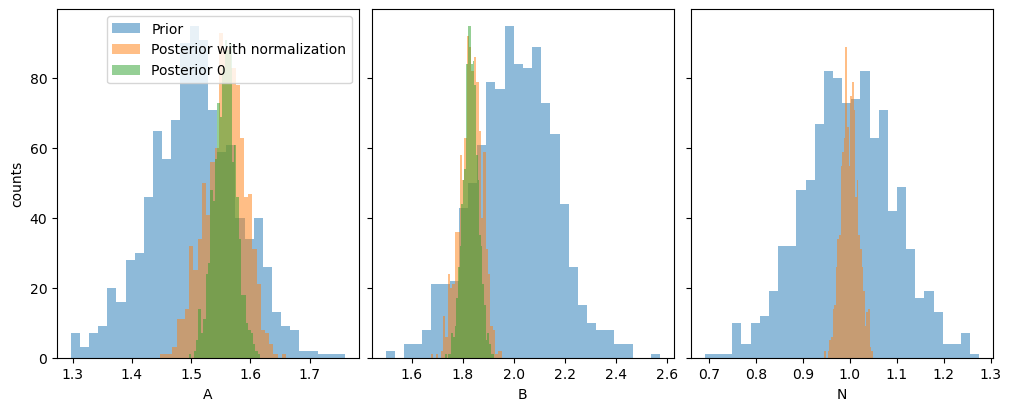

In [849]:
variables = ["A", "B", "N"]
fig, axs = plt.subplots(1,3,figsize=(10,4),layout='constrained', sharey=True)
for i in range(3):
    if i==2:
        axs[i].hist(X1_prior[:,i], bins=30, label="Prior", alpha=0.5)
        axs[i].hist(X1_post_samples[:,i], bins=30, label="Posterior 1", color="C1", alpha=0.5)
    else:
        axs[i].hist(X1_prior[:,i], bins=30, label="Prior", alpha=0.5)
        axs[i].hist(X1_post_samples[:,i], bins=30, label="Posterior with normalization", alpha=0.5)
        axs[i].hist(X0_post_samples[:,i], bins=30, label="Posterior 0", alpha=0.5)

    axs[i].set(
        xlabel=variables[i],
        ylabel="counts" if i==0 else None
    )

    if i==0:
        axs[i].legend()

In [662]:
# Let us try to do it using Monte Carlo
nsmp = 10000
X0_samples = np.random.multivariate_normal(X0, Cov_X0, nsmp)
C0_samples = S0 @ X0_samples.T
r = E0 - C0_samples.T
Chi0 = np.sum(r*r * np.diag(Cov_E0)**(-1), axis=1)
w0 = np.exp(-0.5 * Chi0)

C0_samples_post = np.sum(C0_samples * w0, axis=1) / w0.sum()
print(C0_samples_post)

Cov_C0_samples_post = w0 * (C0_samples.T - C0_samples_post).T @ (C0_samples.T - C0_samples_post) / np.sum(w0)
print(np.sqrt(np.diag(Cov_C0_samples_post))/C0_samples_post)

X0_post = np.sum(X0_samples.T * w0, axis=1) / w0.sum()
print(X0_post)

Cov_X0_post = w0 * (X0_samples - X0_post).T @ (X0_samples - X0_post) / np.sum(w0)
print(np.sqrt(np.diag(Cov_X0_post))/X0_post)

[3.38390173 1.0101102  8.05064993]
[0.01529215 0.01947822 0.01406138]
[1.55558273 1.828319  ]
[0.01327859 0.01734246]


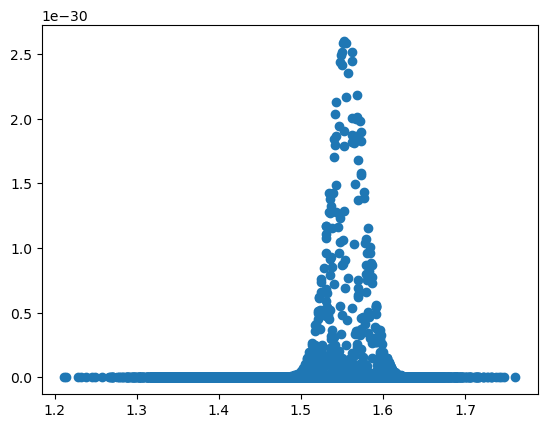

In [670]:
plt.scatter(X0_samples[:,0], w0)

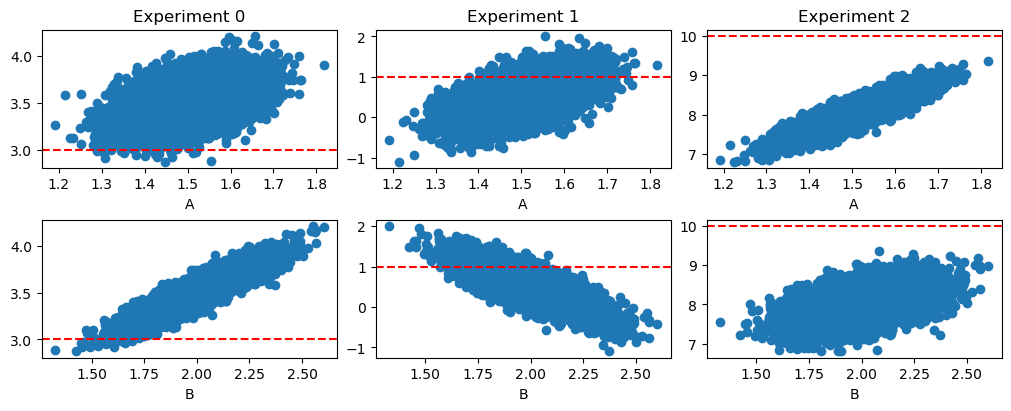

In [654]:
fig, axs = plt.subplots(2, 3, figsize=(5*2,4), layout='constrained')

for i in range(C0_samples.T.shape[1]):
    for j in range(X0_samples.shape[1]):   
        axs[j,i].scatter(X0_samples[:,j], C0_samples.T[:,i])
        axs[j,i].axhline(E0[i], color='red', ls='--')
        if j==0:
            axs[j,i].set(title=f"Experiment {i}", xlabel="A")
        else:
            axs[j,i].set(xlabel="B")



C:\Users\dhouben\AppData\Local\Temp\ipykernel_26564\2530949404.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


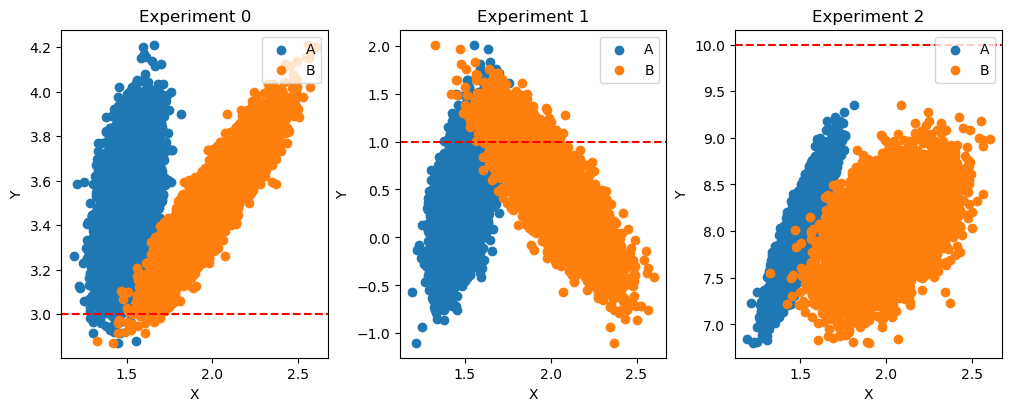

In [655]:
fig, axs = plt.subplots(1, 3, figsize=(5*2,4), layout='constrained')

for i in range(C0_samples.T.shape[1]):
        axs[i].scatter(X0_samples[:,0], C0_samples.T[:,i], label="A")
        axs[i].scatter(X0_samples[:,1], C0_samples.T[:,i], label="B")
        axs[i].axhline(E0[i], color='red', ls='--')

        axs[i].set(
                xlabel="X",
                ylabel="Y",
                title=f"Experiment {i}"
        )

        axs[i].legend(loc="upper right")
fig.show()

In [661]:
C0_samples_post = np.sum(C0_samples * w0, axis=1) / w0.sum()
print(C0_samples_post)

Cov_C0_samples_post = w0 * (C0_samples.T - C0_samples_post).T @ (C0_samples.T - C0_samples_post) / np.sum(w0)
print(np.sqrt(np.diag(Cov_C0_samples_post))/C0_samples_post)

X0_post = np.sum(X0_samples.T * w0, axis=1) / w0.sum()
print(X0_post)

Cov_X0_post = w0 * (X0_samples - X0_post).T @ (X0_samples - X0_post) / np.sum(w0)
print(np.sqrt(np.diag(Cov_X0_post))/X0_post)

[3.38944884 1.01057126 8.0631302 ]
[0.0140611  0.01988592 0.0129854 ]
[1.55789379 1.83155505]
[0.01232857 0.01591705]


In [634]:
Cov_C0_samples_post = w0 * (C0_samples.T - C0_samples_post).T @ (C0_samples.T - C0_samples_post) / np.sum(w0)
print(np.sqrt(np.diag(Cov_C0_samples_post))/C0_samples_post)

[0.01427531 0.0196437  0.01328302]


In [635]:
X0_post = np.sum(X0_samples.T * w0, axis=1) / w0.sum()
print(X0_post)
Cov_X0_post = w0 * (X0_samples - X0_post).T @ (X0_samples - X0_post) / np.sum(w0)
print(np.sqrt(np.diag(Cov_X0_post))/X0_post)

[1.55686859 1.83047531]
[0.01267991 0.01599964]


In [660]:
Cov_X0

array([[0.005625, 0.      ],
       [0.      , 0.0256  ]])

In [659]:
BMC(S0, X0, Cov_X0, E0, Cov_E0)

[11014.60474464  8513.01231988  8599.79272636  8655.21366546
 14977.16842099 10896.06673624 14275.7447223  10585.88879351
 11309.03723178 15192.42027382 12419.4571     12889.28086284
 10080.10493654 11721.36362322  9664.9082322  11173.69199004
 12461.30536824 10200.91023917 10518.39847644 12401.49670038
 10301.63368244 13166.099933   12821.34151962 11187.0953319
 10224.21347048 10137.1810235   9636.37636544 13945.07876568
 11296.05981397 14869.00987528 12324.46560742  9644.1541644
  9060.31483565 12254.12570966 13852.58993052 11418.42557507
 13627.24097851 11703.16549351 10082.65276972  6960.28916218
 10658.15154288 12760.66548508 10386.36531239 13350.96019859
  8482.81284948 12263.52972282 10400.67715527 14575.39510481
 11907.54969728  8678.1289044  10518.70720944 15558.73870986
  6908.9341419  13122.24562149  7609.21952205 15104.948571
 11174.81604479 14238.92321815 11335.016048   16869.41628652
  8987.35157261 12236.34974066 13625.73428814 13037.27071376
 16982.43533829 14065.463498

C:\Users\dhouben\AppData\Local\Temp\ipykernel_26564\2422854139.py:10: RuntimeWarning: invalid value encountered in divide
  C_post = np.sum(C_samples * w, axis=1) / w.sum()
C:\Users\dhouben\AppData\Local\Temp\ipykernel_26564\2422854139.py:11: RuntimeWarning: divide by zero encountered in divide
  Cov_C_post = w * (C_samples.T - C_post).T @ (C_samples.T - C_post) / np.sum(w)
C:\Users\dhouben\AppData\Local\Temp\ipykernel_26564\2422854139.py:12: RuntimeWarning: invalid value encountered in divide
  X_post = np.sum(X_samples.T * w, axis=1) / w.sum()


ValueError: operands could not be broadcast together with shapes (10000,) (2,1000) 

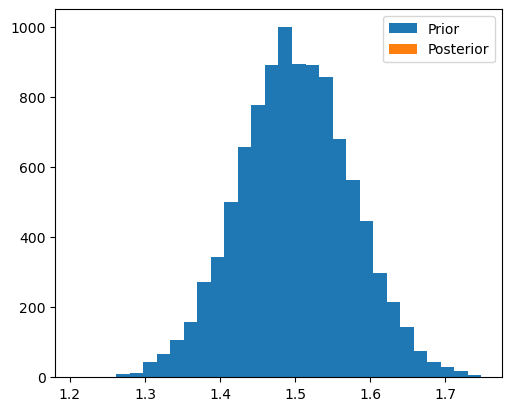

In [606]:
fig, ax = plt.subplots(figsize=(5,4), layout="constrained")

ax.hist(X0_samples[:,0], bins=30, label="Prior")
ax.hist(X0_samples[:,0], weights=w0, bins=30, label="Posterior")

ax.legend()